In [1]:

import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

# Load dataset
df = pd.read_csv(r"cardekho_data.csv")

# Create car age column
df['Car_Age'] = 2026 - df['Year']

# Drop unwanted columns
df.drop(['Car_Name', 'Year'], axis=1, inplace=True)

# Features and target
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# Convert categorical columns into numeric
X = pd.get_dummies(X)

# Handle missing values
X = X.fillna(X.mean())


In [2]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [3]:
# apply decision tree regressor
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)



,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

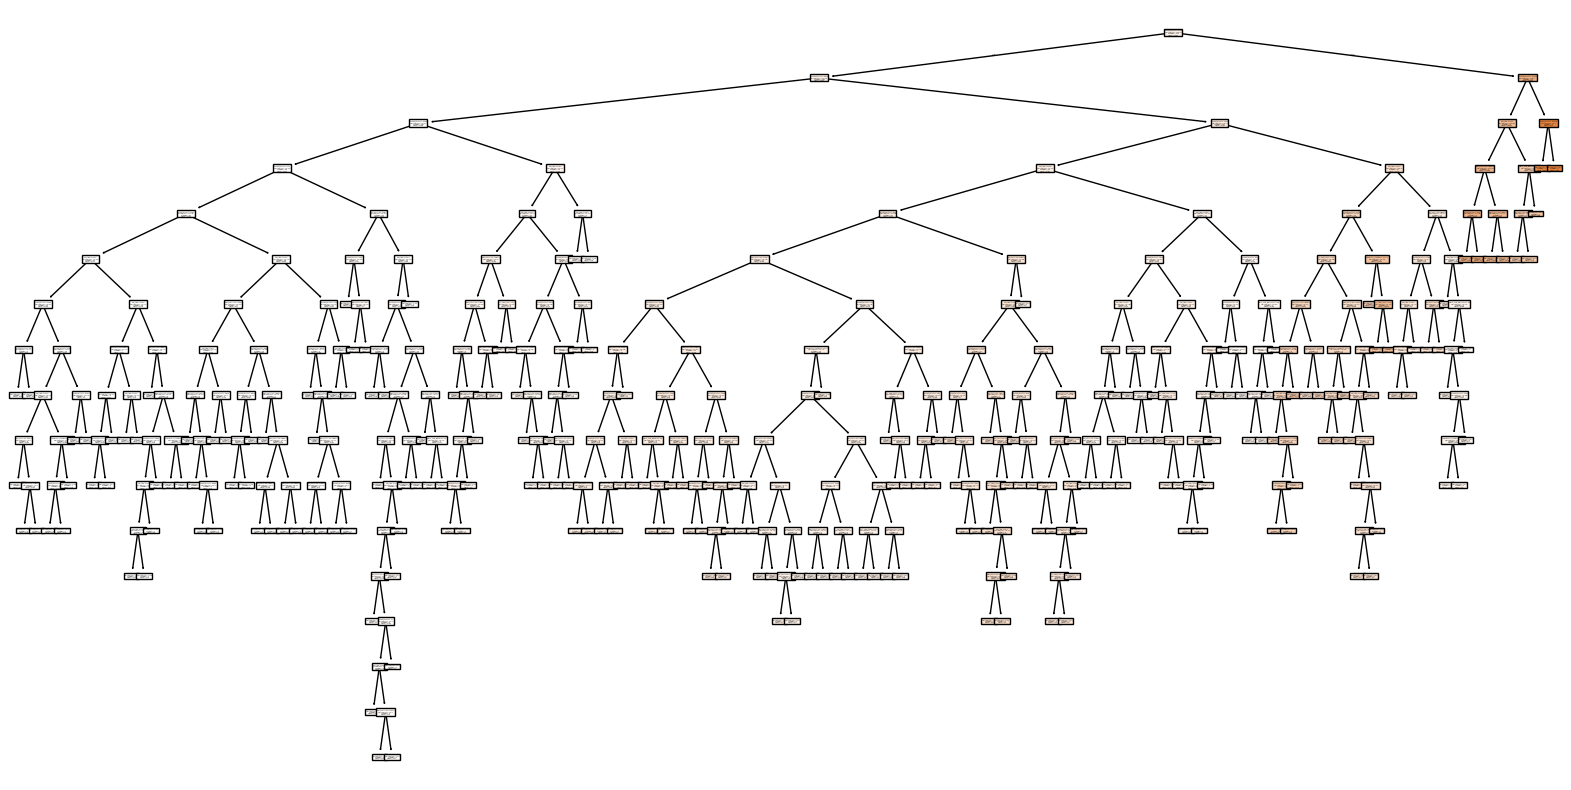

In [4]:
# visualize the decision tree
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=X.columns)
plt.show()


In [5]:

# prediction
y_pred = model.predict(X_test)
y_pred


array([ 0.5 , 11.25,  4.1 ,  0.2 ,  7.05,  5.95,  1.11,  0.5 ,  0.48,
        7.2 ,  7.25,  1.25,  7.5 ,  0.45,  4.75,  2.35,  1.25, 14.25,
        0.48,  1.75,  0.25,  8.75,  4.5 ,  2.7 ,  0.45,  2.9 ,  5.25,
        3.1 ,  1.15,  1.15,  0.25, 11.25,  0.45,  2.25,  7.75,  3.9 ,
        5.85,  5.9 ,  2.55,  5.9 ,  3.49,  3.35,  5.3 ,  0.6 ,  6.75,
        0.65,  8.5 ,  4.35,  3.1 ,  2.9 ,  4.75,  1.45, 19.99, 20.75,
        5.95,  9.15,  5.25,  7.75,  2.65,  6.4 ,  0.25])

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Mean Absolute Error:\n", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:\n", mean_squared_error(y_test, y_pred))
print("R2 Score:\n", r2_score(y_test, y_pred))



Mean Absolute Error:
 0.7331147540983607
Mean Squared Error:
 1.2782295081967214
R2 Score:
 0.9445106545019151


In [7]:
params = {
    'criterion': ['squared_error', 'friedman_mse'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'splitter': ['best', 'random']
}
params



{'criterion': ['squared_error', 'friedman_mse'],
 'max_depth': [None, 10, 20, 30],
 'min_samples_split': [2, 5, 10],
 'splitter': ['best', 'random']}

In [8]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=params, cv=5)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Mean Absolute Error:\n", mean_absolute_error(y_test, y_pred_best))
print("Mean Squared Error:\n", mean_squared_error(y_test, y_pred_best))
print("R2 Score:\n", r2_score(y_test, y_pred_best))



Best Parameters: {'criterion': 'squared_error', 'max_depth': None, 'min_samples_split': 5, 'splitter': 'best'}
Mean Absolute Error:
 0.6869672131147544
Mean Squared Error:
 1.150206284153006
R2 Score:
 0.9500682831321307


In [9]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Squared Error:\n", mse)
print("Root Mean Squared Error:\n", rmse)
print("R2 Score:\n", r2_score(y_test, y_pred))


Mean Squared Error:
 1.2782295081967214
Root Mean Squared Error:
 1.130588124914074
R2 Score:
 0.9445106545019151
